[2026-07-31 22:30:24] [info     ] ━━ 构建训练宽表 ━━
[2026-07-31 22:34:13] [info     ] build_daily 完成                 atoms=64 rows=517955 sec=229.3
[2026-07-31 22:34:48] [info     ] 训练样本 239753 行 / 241 天
[2026-07-31 22:34:48] [info     ] ━━ 构建验证面板 (2024) ━━
[2026-07-31 22:38:23] [info     ] build_daily 完成                 atoms=64 rows=517237 sec=214.7
[2026-07-31 22:38:56] [info     ] prepare_panel 2024-01-01~2024-12-31 days=240 rows=238026
[2026-07-31 22:38:56] [info     ] ━━ 遗传算法进化 ━━
[2026-07-31 22:40:15] [info     ] gen000  train_IC=+0.0147  val_IC=+0.0140  size=3  78.6s  neg(ts_rank(ch_vol_close_sum,3))
[2026-07-31 22:41:23] [info     ] gen001  train_IC=+0.0147  val_IC=+0.0140  size=3  67.6s  neg(ts_rank(ch_vol_close_sum,3))
[2026-07-31 22:42:57] [info     ] gen002  train_IC=+0.0147  val_IC=+0.0140  size=3  94.2s  neg(ts_rank(ch_vol_close_sum,3))
[2026-07-31 22:44:50] [info     ] gen003  train_IC=+0.0147  val_IC=+0.0140  size=3  112.8s  neg(ts_rank(ch_vol_close_sum,3))
[2026-07-31 22:4

时段,IC
2024-01-15~2024-02-08,0.0182
2024-09-24~2024-10-08,0.0564

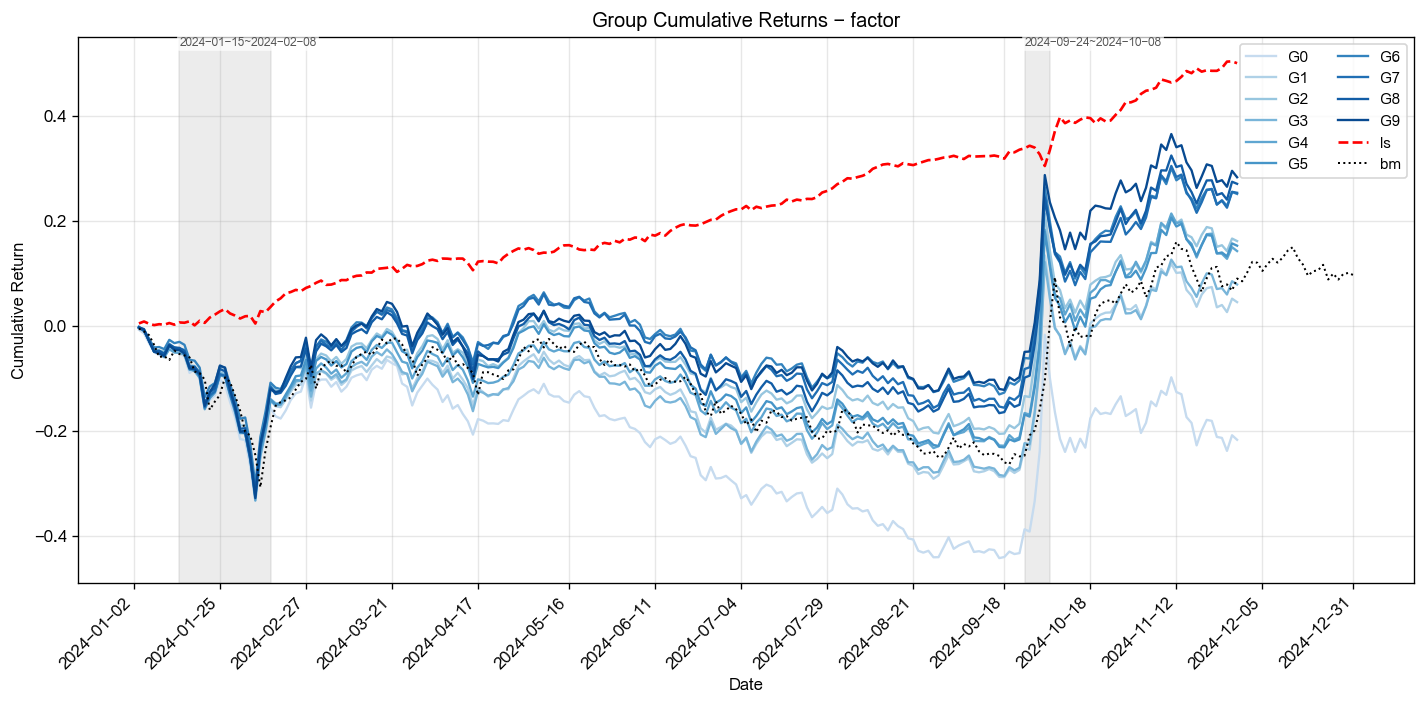
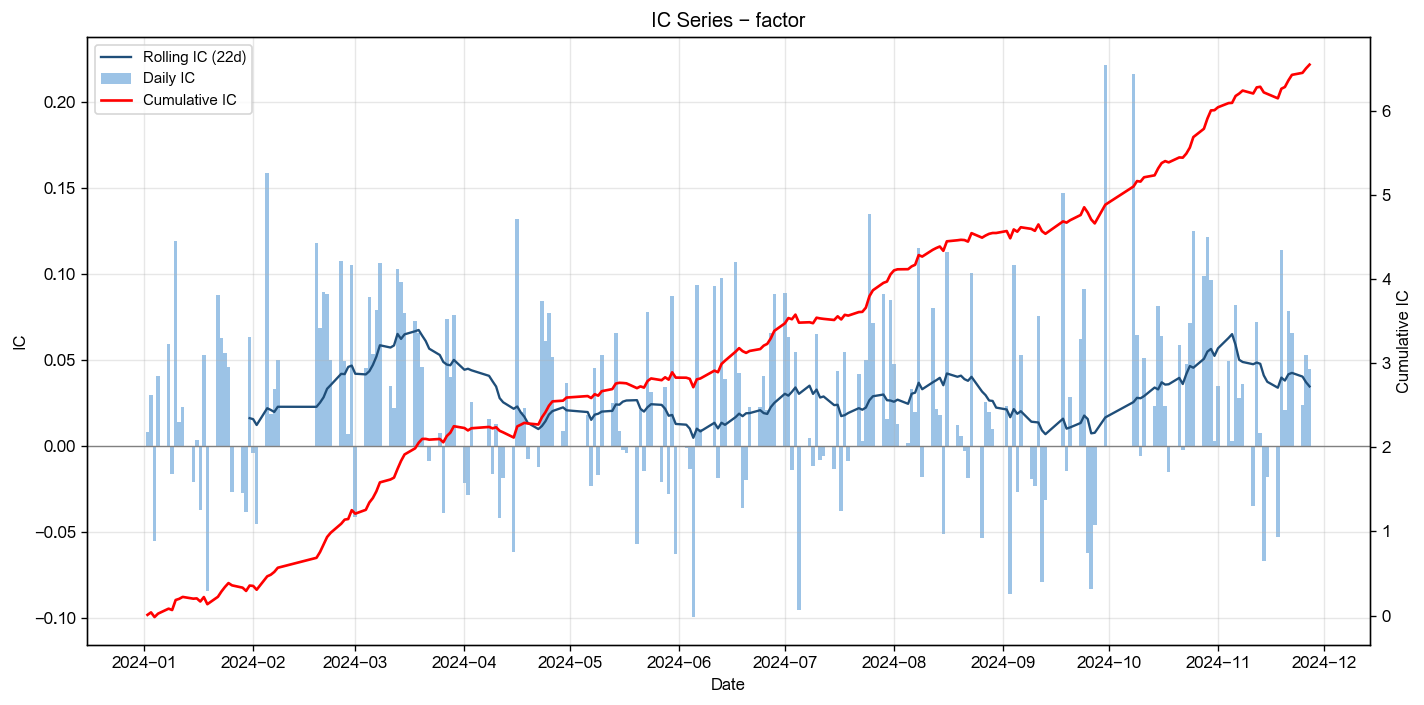
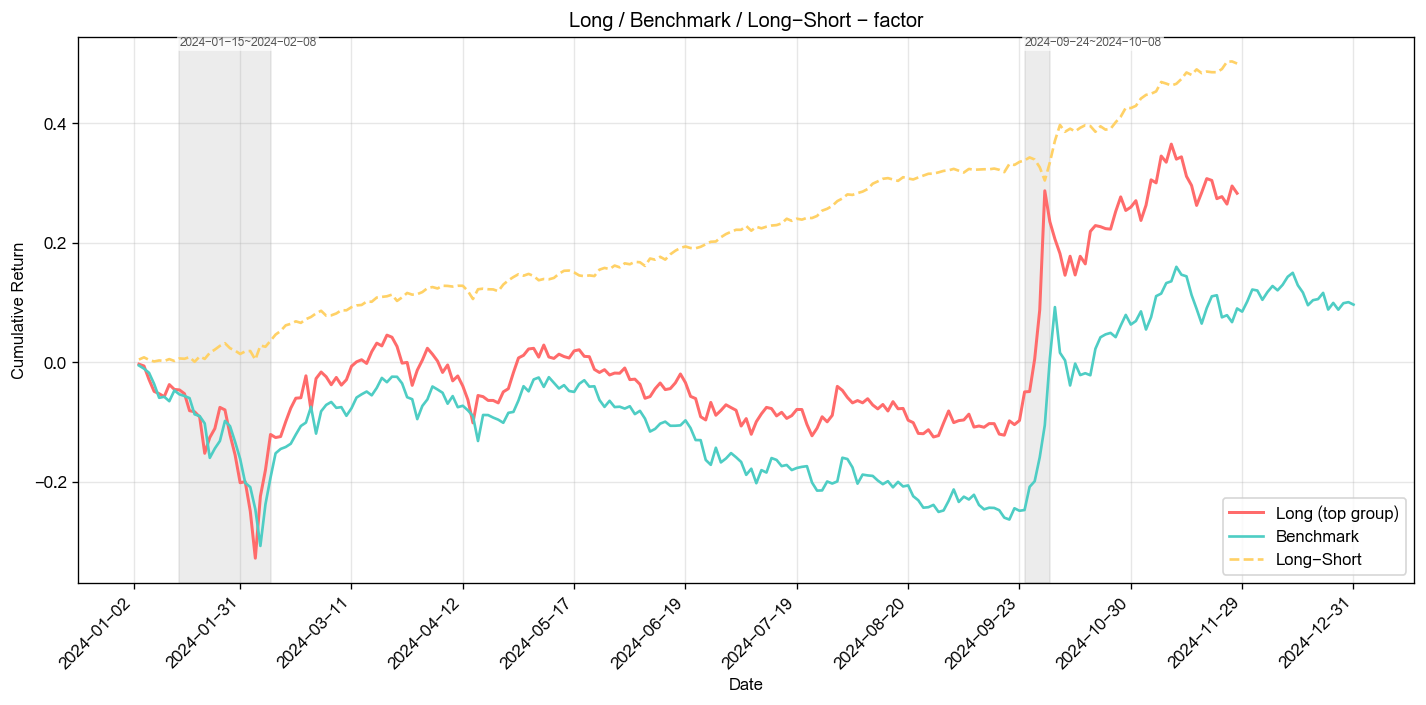
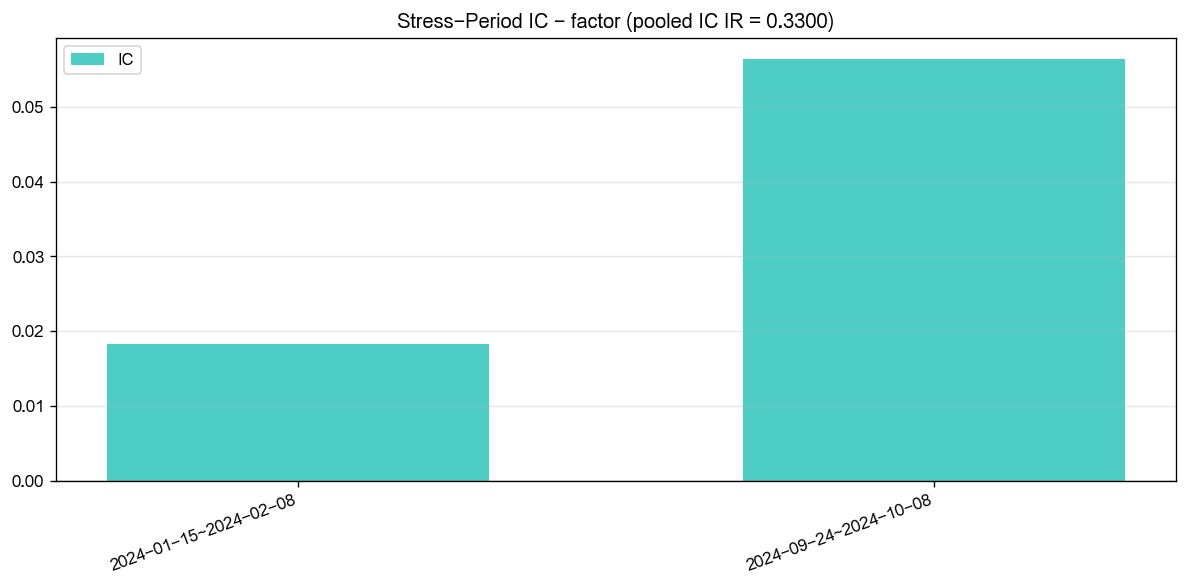
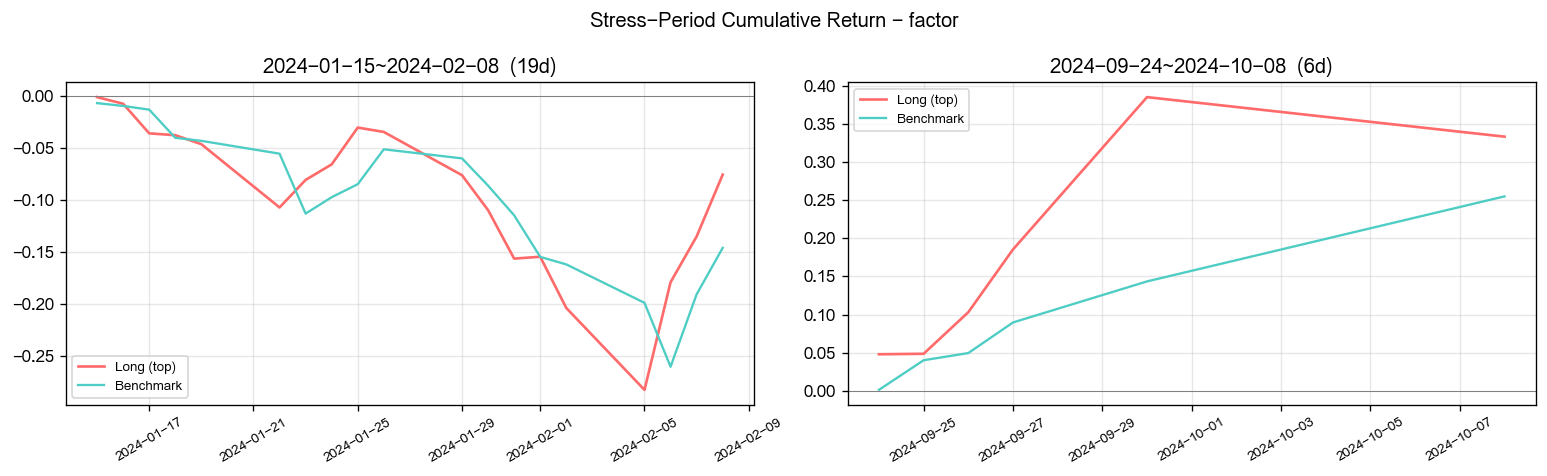

[2026-07-31 23:24:41] [info     ] ========== 因子池回归 ==========
[2026-07-31 23:24:41] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-31 23:24:42] [info     ] 获取收益率数据, 耗时: 0.7578 秒
[2026-07-31 23:24:43] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.825 秒
[2026-07-31 23:24:43] [info     ] 统计 回归结果, 耗时: 0.1062 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,3.9809,0.0450,0.0113,1.0000
2,rsi_12,1.9119,0.0440,0.0230,1.0000
3,pb,1.6221,0.0112,0.0069,1.0000
4,gross_profit_rate_ttm,1.4951,0.0067,0.0045,1.0000
5,netflow_amount_main,1.4726,0.0233,0.0158,1.0000
6,net_profit_rate_ttm,1.4154,0.0040,0.0028,0.8000
7,cci_14,1.3913,0.0327,0.0235,0.9000
8,netflow_amount_rate_main,1.3792,0.0100,0.0073,1.0000
9,ps_ttm,1.3310,0.0031,0.0023,1.0000
10,amount,1.3290,0.0111,0.0083,0.9000

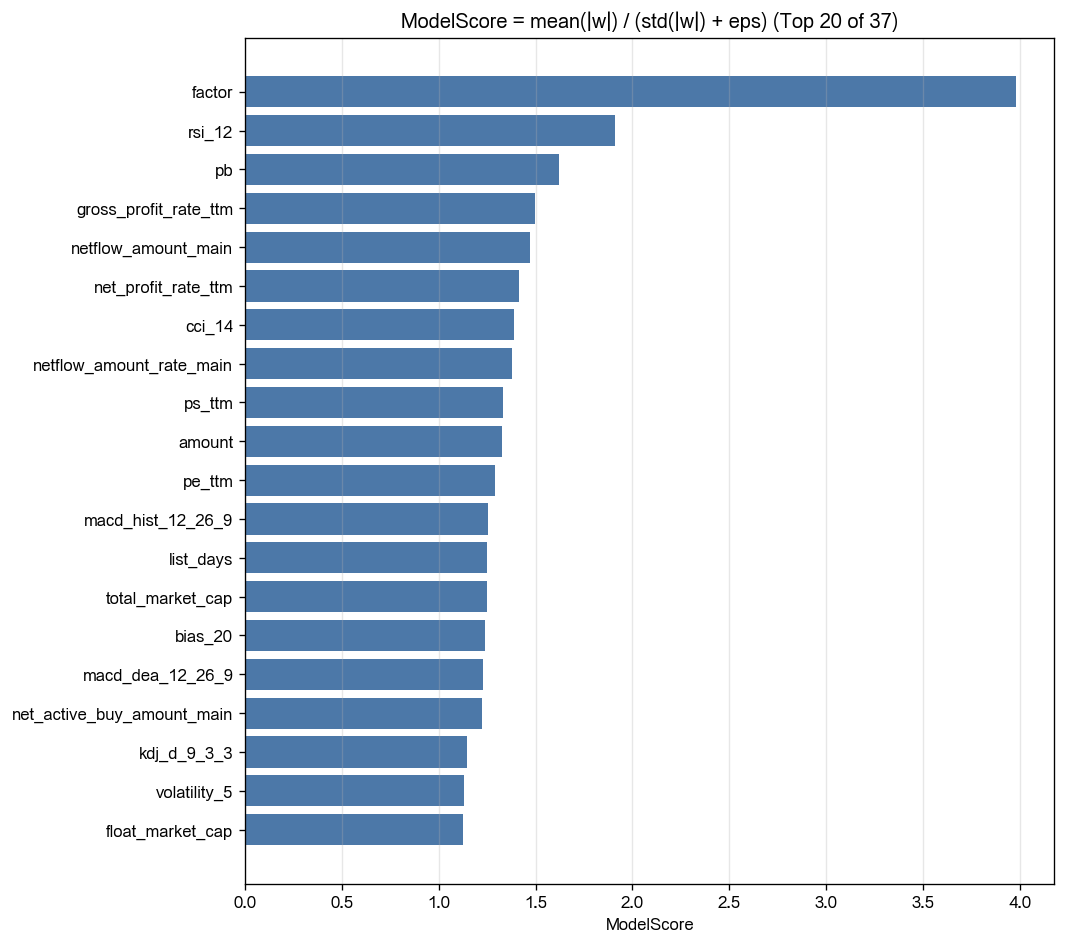
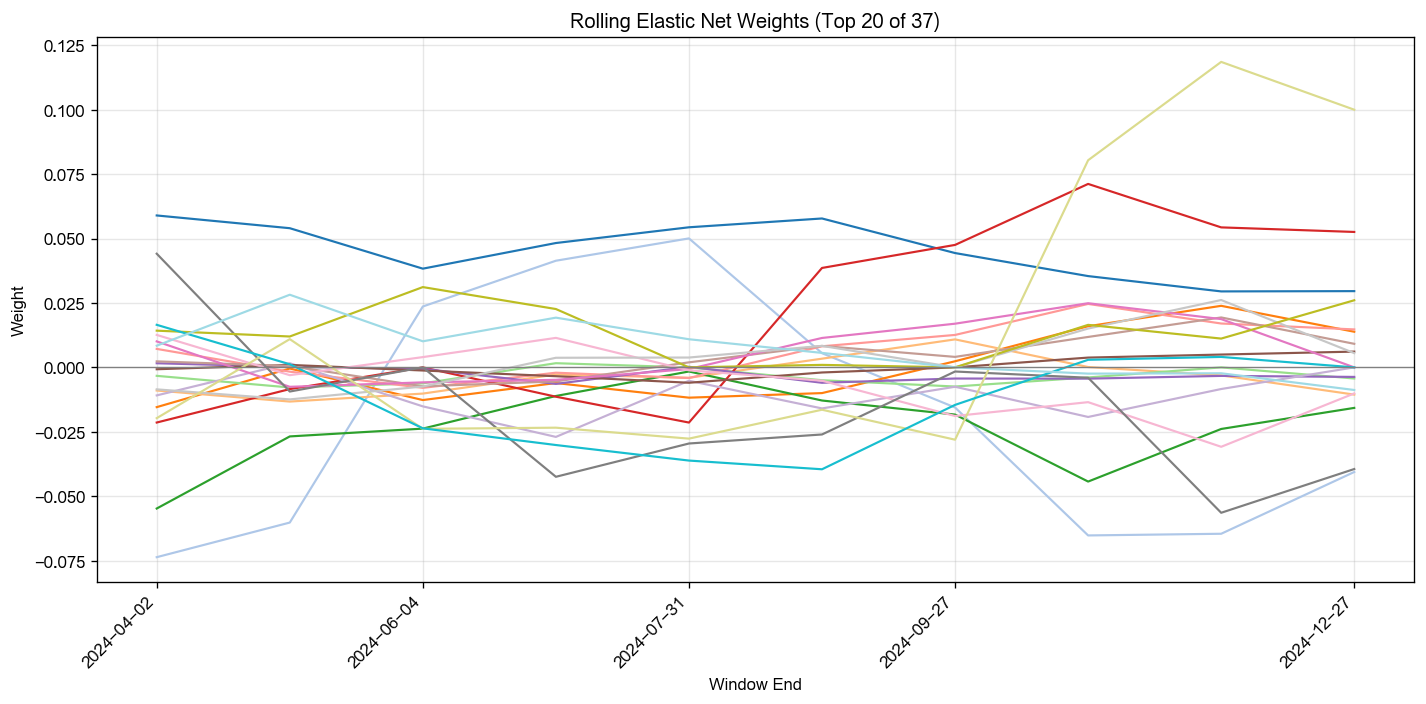
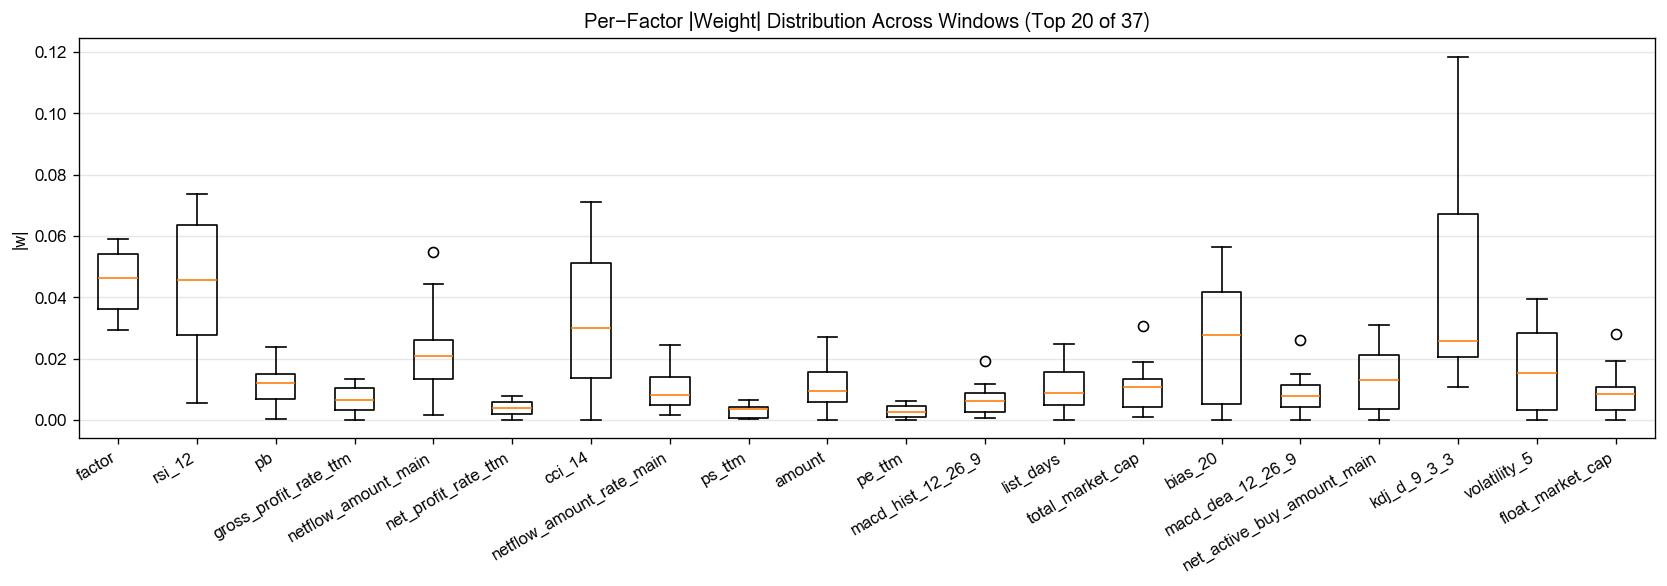
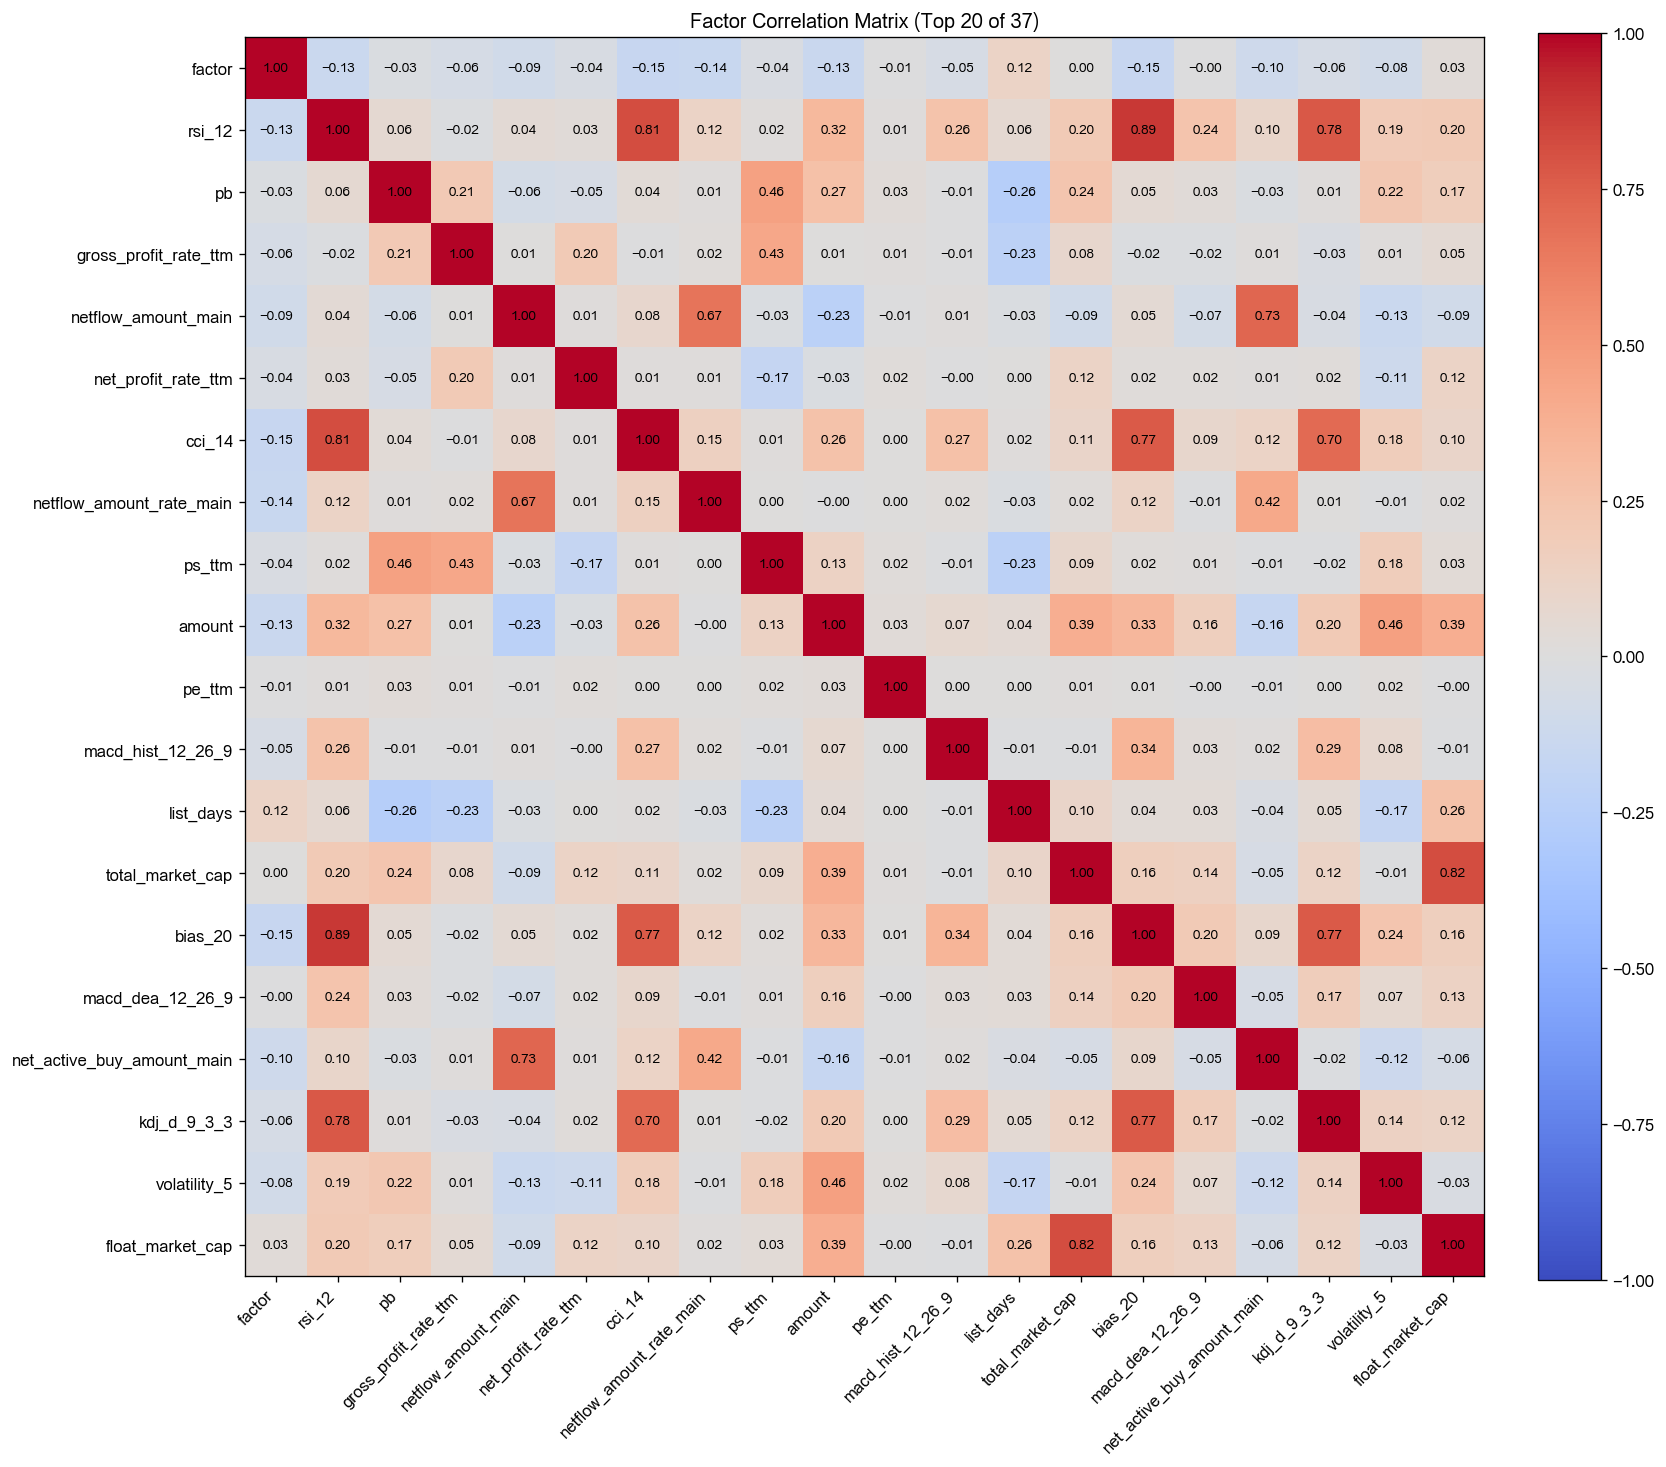

[2026-07-31 23:24:46] [warning  ] 返回的Outputs实例(size=35175947) 大于 64K, 将不会被缓存
[2026-07-31 23:24:46] [info     ] bigalpha_eval.v4 运行完成 [40.237s].


In [1]:
def main(datasources, start_date, end_date):
    """
    BigAlpha 2026 · AI 智能赛道 · 遗传算法因子 v2
    重构：train()/predict() 模板
    新增：① 时序算子  ② 2024 验证集  ③ 集成 hof
    修改：移除每代重采样，优化内存管理
    """

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  Imports
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    import time, gc, random
    from copy import deepcopy
    import numpy as np
    import pandas as pd
    import dai
    import structlog

    logger = structlog.get_logger()

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  Config
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    SEED = 42; random.seed(SEED); np.random.seed(SEED)

    TRAIN_START = '2021-01-01'
    TRAIN_END   = '2023-12-31'
    VAL_START   = '2024-01-01'
    VAL_END     = '2024-12-31'

    GENERATIONS     = 25
    POP_SIZE        = 150
    ELITE           = 20
    PARSIMONY       = 0.005
    NOVELTY_THRESH  = 0.7
    PATIENCE        = 6
    MAX_SIZE        = 15
    MIN_STOCKS      = 50
    TRAIN_BAR1M = 'bigalpha_2026_stock_bar1m'

    TS_WINDOWS = [3, 5, 10, 20]

    BARRA = ["SIZE","BETA","MOMENTUM","RESVOL","SIZENL",
             "BTOP","LIQUIDTY","EARNYILD","GROWTH","LEVERAGE"]
    INDUSTRY = ["AGRIFOREST","MINING","CHEM","IRONSTEEL","NONFERMETAL",
                "ELECTRONICS","AUTO","HOUSEAPP","FOODBEVER","TEXTILE",
                "LIGHTINDUS","HEALTH","UTILITIES","TRANSPORTATION","REALESTATE",
                "COMMETRADE","LEISERVICE","BANK","NONBANKFINAN","CONGLOMERATES",
                "CONMAT","BUILDDECO","ELECEQP","MACHIEQUIP","AERODEF",
                "COMPUTER","MEDIA","TELECOM","COAL","PETRO","ENVP","BEAUTY"]

    CHANNELS = [
        "ch_ret_mean","ch_ret_std","ch_close_mean","ch_close_std",
        "ch_close_max","ch_close_min","ch_high_max","ch_low_min",
        "ch_vol_sum","ch_vol_mean","ch_vol_std","ch_vol_max",
        "ch_amt_sum","ch_amt_mean","ch_amt_std","ch_amt_max",
        "ch_deal_sum","ch_deal_mean",
        "ch_bp1_mean","ch_bp1_std","ch_ap1_mean","ch_ap1_std",
        "ch_mid_mean","ch_spread_mean","ch_spread_std","ch_spread_raw_mean",
        "ch_bv1_mean","ch_bv1_std","ch_av1_mean","ch_av1_std",
        "ch_bv5_mean","ch_av5_mean","ch_obi1_mean","ch_obi1_std",
        "ch_obi5_mean","ch_obi5_std",
        "ch_vol_open_sum","ch_amt_open_sum","ch_close_open_mean",
        "ch_bv1_open_mean","ch_av1_open_mean","ch_obi1_open_mean",
        "ch_vol_close_sum","ch_amt_close_sum","ch_close_close_mean",
        "ch_bv1_close_mean","ch_av1_close_mean","ch_obi1_close_mean",
        "ch_ret_open15","ch_vol_open15_sum","ch_amt_open15_sum",
        "ch_close_open15_mean","ch_bv1_open15_mean","ch_av1_open15_mean",
        "ch_obi1_open15_mean",
        "ch_ret_close15","ch_vol_close15_sum","ch_amt_close15_sum",
        "ch_close_close15_mean","ch_bv1_close15_mean","ch_av1_close15_mean",
        "ch_obi1_close15_mean",
        "ch_pre_close","ch_adjust_factor",
    ]

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  Safe Operators
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    def _sdiv(a, b): return np.where(np.abs(b) > 1e-8, a / b, 0.0)
    def _slog(a):    return np.log1p(np.abs(a)) * np.sign(a)
    def _ssqrt(a):   return np.sqrt(np.abs(a)) * np.sign(a)

    BIN_OPS = {"+": np.add, "-": np.subtract, "*": np.multiply,
               "/": _sdiv, "max": np.maximum, "min": np.minimum}
    UNARY   = {"abs": np.abs, "neg": np.negative, "sign": np.sign,
               "log": _slog, "sqrt": _ssqrt,
               "sq": lambda a: np.clip(a*a, -1e12, 1e12),
               "inv": lambda a: _sdiv(1.0, a)}

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  Cross-Sectional Context
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    class CSContext:
        def __init__(self, dates):
            codes = pd.factorize(dates, sort=False)[0]
            self.codes = codes
            self.bounds = np.r_[0, np.flatnonzero(np.diff(codes)) + 1]
            self.counts = np.diff(np.r_[self.bounds, len(dates)])
            self.count_of_row = self.counts[codes]
            self.start_of_row = self.bounds[codes]

        def zscore(self, v):
            s = np.add.reduceat(v, self.bounds)
            mean = np.repeat(s / self.counts, self.counts)
            sq   = np.add.reduceat(v**2, self.bounds)
            var  = sq / self.counts - (s / self.counts)**2
            std  = np.repeat(np.sqrt(np.maximum(var, 0.0)), self.counts) + 1e-8
            return np.clip((v - mean) / std, -3, 3)

        def demean(self, v):
            s = np.add.reduceat(v, self.bounds)
            return v - np.repeat(s / self.counts, self.counts)

        def rank(self, v):
            order = np.lexsort((v, self.codes))
            pos = np.empty(len(v)); pos[order] = np.arange(len(v))
            return (pos - self.start_of_row) / np.maximum(self.count_of_row - 1, 1)

    CS_OPS = {"cs_zscore": "zscore", "cs_rank": "rank", "cs_demean": "demean"}

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  Time-Series Context
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # — rolling helpers (per-instrument segment) —
    def _ts_mean(seg, w):
        n = len(seg)
        if n == 0: return seg.copy()
        cs = np.cumsum(np.r_[0.0, seg])
        out = np.empty(n)
        k = min(w, n)
        out[:k] = cs[1:k+1] / np.arange(1, k+1, dtype=np.float32)
        if n > w:
            out[w:] = (cs[w+1:n+1] - cs[1:n+1-w]) / w
        return out

    def _ts_std(seg, w):
        n = len(seg)
        if n < 2: return np.zeros(n)
        cs  = np.cumsum(np.r_[0.0, seg])
        cs2 = np.cumsum(np.r_[0.0, seg**2])
        out = np.zeros(n)
        for i in range(1, min(w, n)):
            k = i + 1
            m = cs[k] / k
            out[i] = np.sqrt(max(cs2[k] / k - m*m, 0.0))
        if n >= w:
            s  = cs[w:n+1]  - cs[:n+1-w]
            s2 = cs2[w:n+1] - cs2[:n+1-w]
            m  = s / w
            out[w-1:] = np.sqrt(np.maximum(s2/w - m*m, 0.0))
        return out

    def _ts_delta(seg, w):
        out = np.zeros(len(seg))
        if len(seg) > w:
            out[w:] = seg[w:] - seg[:-w]
        return out

    def _ts_max(seg, w):
        n = len(seg)
        if n == 0: return seg.copy()
        out = np.empty(n)
        for i in range(n):
            out[i] = np.max(seg[max(0, i+1-w):i+1])
        return out

    def _ts_min(seg, w):
        n = len(seg)
        if n == 0: return seg.copy()
        out = np.empty(n)
        for i in range(n):
            out[i] = np.min(seg[max(0, i+1-w):i+1])
        return out

    def _ts_rank(seg, w):
        n = len(seg)
        if n == 0: return seg.copy()
        out = np.empty(n)
        for i in range(n):
            lo = max(0, i+1-w)
            window = seg[lo:i+1]
            out[i] = np.sum(window <= seg[i]) / len(window)
        return out

    TS_FUNCS = {'ts_mean': _ts_mean, 'ts_std': _ts_std, 'ts_delta': _ts_delta,
                'ts_max': _ts_max,   'ts_min': _ts_min, 'ts_rank': _ts_rank}
    TS_OP_NAMES = list(TS_FUNCS.keys())

    class TsContext:
        """按 instrument 分组，对每段时序施加 rolling 算子"""
        def __init__(self, dates, instruments):
            n = len(dates)
            icodes = pd.factorize(instruments, sort=True)[0]
            dcodes = pd.factorize(dates, sort=True)[0]
            order = np.lexsort((dcodes, icodes))       # (inst, date) 排序
            self.to_ts = order
            self.from_ts = np.empty(n, dtype=np.intp)
            self.from_ts[order] = np.arange(n)
            si = icodes[order]
            if n > 0:
                chg = np.flatnonzero(si[1:] != si[:-1]) + 1
                self.starts = np.r_[0, chg]
                self.ends   = np.r_[chg, n]
            else:
                self.starts = np.array([], dtype=int)
                self.ends   = np.array([], dtype=int)

        def apply(self, v_orig, op, window):
            v = v_orig[self.to_ts]
            result = np.empty_like(v)
            func = TS_FUNCS[op]
            for a, b in zip(self.starts, self.ends):
                result[a:b] = func(v[a:b], window)
            return result[self.from_ts]

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  Expression Tree
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    class Leaf:
        __slots__ = ('feat',)
        def __init__(self, feat): self.feat = feat
        def __repr__(self): return self.feat
        def size(self): return 1

    class Const:
        __slots__ = ('val',)
        def __init__(self, val=None):
            self.val = val if val is not None else round(random.uniform(-2, 2), 2)
        def __repr__(self): return str(self.val)
        def size(self): return 1

    class Bin:
        __slots__ = ('op','l','r')
        def __init__(self, op, l, r): self.op, self.l, self.r = op, l, r
        def __repr__(self):
            return (f"({self.l} {self.op} {self.r})" if self.op in "+-*/"
                    else f"{self.op}({self.l}, {self.r})")
        def size(self): return 1 + self.l.size() + self.r.size()

    class Un:
        __slots__ = ('op','c')
        def __init__(self, op, c): self.op, self.c = op, c
        def __repr__(self): return f"{self.op}({self.c})"
        def size(self): return 1 + self.c.size()

    class Cs:
        __slots__ = ('op','c')
        def __init__(self, op, c): self.op, self.c = op, c
        def __repr__(self): return f"{self.op}({self.c})"
        def size(self): return 1 + self.c.size()

    class Ts:
        __slots__ = ('op','c','window')
        def __init__(self, op, c, window): self.op, self.c, self.window = op, c, window
        def __repr__(self): return f"{self.op}({self.c},{self.window})"
        def size(self): return 1 + self.c.size()

    # — evaluation —
    def _ev_raw(node, F, idx, cs, ts):
        t = type(node)
        if t is Leaf:  return F[:, idx[node.feat]]
        if t is Const: return np.full(F.shape[0], node.val, dtype=np.float32)
        if t is Bin:   return BIN_OPS[node.op](_ev_raw(node.l, F, idx, cs, ts),
                                               _ev_raw(node.r, F, idx, cs, ts))
        if t is Un:    return UNARY[node.op](_ev_raw(node.c, F, idx, cs, ts))
        if t is Cs:    return getattr(cs, CS_OPS[node.op])(
                              _ev_raw(node.c, F, idx, cs, ts))
        if t is Ts:    return ts.apply(_ev_raw(node.c, F, idx, cs, ts),
                                       node.op, node.window)

    def ev(node, F, idx, cs, ts):
        return np.nan_to_num(_ev_raw(node, F, idx, cs, ts),
                             nan=0.0, posinf=0.0, neginf=0.0)

    # — generation / mutation —
    def rand_tree(feats, depth=3):
        if depth <= 0 or random.random() < 0.3:
            return Leaf(random.choice(feats)) if random.random() < 0.88 else Const()
        r = random.random()
        if r < 0.25:
            return Bin(random.choice(list(BIN_OPS)),
                       rand_tree(feats, depth-1), rand_tree(feats, depth-1))
        elif r < 0.45:
            return Un(random.choice(list(UNARY)), rand_tree(feats, depth-1))
        elif r < 0.70:
            return Cs(random.choice(list(CS_OPS)), rand_tree(feats, depth-1))
        else:
            return Ts(random.choice(TS_OP_NAMES), rand_tree(feats, depth-1),
                      random.choice(TS_WINDOWS))

    def all_slots(node):
        slots = [(None, None)]
        if type(node) is Bin:
            slots += [(node,"l")] + all_slots(node.l)
            slots += [(node,"r")] + all_slots(node.r)
        elif type(node) in (Un, Cs, Ts):
            slots += [(node,"c")] + all_slots(node.c)
        return slots

    def mutate(node, feats):
        node = deepcopy(node)
        pa, attr = random.choice(all_slots(node))
        sub = rand_tree(feats, depth=2)
        if pa is None: return sub
        setattr(pa, attr, sub)
        return node if node.size() <= MAX_SIZE else rand_tree(feats, 3)

    def crossover(a, b, feats):
        a, b = deepcopy(a), deepcopy(b)
        pa, attr = random.choice(all_slots(a))
        sb_pa, sb_attr = random.choice(all_slots(b))
        sub = b if sb_pa is None else getattr(sb_pa, sb_attr)
        if pa is None:
            return sub if sub.size() <= MAX_SIZE else rand_tree(feats, 3)
        setattr(pa, attr, sub)
        return a if a.size() <= MAX_SIZE else rand_tree(feats, 3)

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  Fitness Context
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    class FitCtx:
        """
        缓存一个面板的特征矩阵 / 标签 / 风险矩阵。
        已移除所有重采样及内部冗余的 Panel DataFrame 保留逻辑。
        """
        def __init__(self, panel, feats):
            # 初始化时立刻将需要的数据转为 numpy 并剥离 DataFrame，节省大内存
            self.F = np.ascontiguousarray(panel[feats].to_numpy(np.float32))
            self.colidx = {c: i for i, c in enumerate(feats)}
            
            dates = panel['date'].to_numpy()
            instruments = panel['instrument'].to_numpy()
            self.cs = CSContext(dates)
            self.ts = TsContext(dates, instruments)

            self.day_slices = [(self.cs.bounds[i],
                                self.cs.bounds[i] + self.cs.counts[i])
                               for i in range(len(self.cs.counts))]

            # 预计算 QR（风险中性 IC）
            risk_cols = [c for c in BARRA + INDUSTRY if c in panel.columns]
            R = panel[risk_cols].fillna(0).to_numpy(np.float32) if risk_cols else None
            y = panel['y_neutral'].to_numpy(np.float32)

            self.Q, self.yres, self.ynorm, self.keep = [], [], [], []
            for (a, b) in self.day_slices:
                if b - a < MIN_STOCKS:
                    self.Q.append(None); self.yres.append(None)
                    self.ynorm.append(None); self.keep.append(False)
                    continue
                X = (np.c_[np.ones(b-a), R[a:b]] if R is not None
                     else np.ones((b-a, 1)))
                q, _ = np.linalg.qr(X)
                yr = y[a:b].copy()
                yr = yr - q @ (q.T @ yr)
                yr = yr - yr.mean()
                self.Q.append(q); self.yres.append(yr)
                self.ynorm.append(np.linalg.norm(yr) + 1e-12)
                self.keep.append(True)

        def score(self, node):
            try:
                fac = ev(node, self.F, self.colidx, self.cs, self.ts)
            except Exception:
                return -1.0, 0.0
            if fac.std() < 1e-9:
                return -1.0, 0.0
            ics = []
            for k, (a, b) in enumerate(self.day_slices):
                if not self.keep[k]: continue
                f = fac[a:b]
                v = self.Q[k].T @ f
                n2 = np.sum(f**2) - np.sum(v**2)
                if n2 < 1e-18: continue
                ics.append((f @ self.yres[k]) / (np.sqrt(n2) * self.ynorm[k]))
            if len(ics) < 20:
                return -1.0, 0.0
            return float(np.mean(ics)), float(np.std(ics))

        def factor_values(self, node):
            return self.cs.zscore(ev(node, self.F, self.colidx, self.cs, self.ts))

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  GA Engine
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    def run_ga(fit, val_fit, feats):
        pop = [rand_tree(feats, 3) for _ in range(POP_SIZE)]
        hof = []
        best_ever = -1e9; stall = 0

        for gen in range(GENERATIONS):
            t0 = time.time()

            # — 训练集评分 —
            scores = [fit.score(ind) for ind in pop]
            ranked = []
            for (m, s), ind in zip(scores, pop):
                ir = m / (s + 1e-8) if s > 0 else m * 5
                ranked.append((ir - PARSIMONY * ind.size(), ir, m, ind))
            ranked.sort(key=lambda x: -x[0])
            _, ir_best, ic_best, best_ind = ranked[0]

            # — ★ 验证集筛 hof（top-8 在 val 上评分）—
            for _, _, ic_i, ind in ranked[:8]:
                if ic_i <= 0: continue
                v_ic, v_std = val_fit.score(ind)
                if v_ic <= 0: continue
                v_ir = v_ic / (v_std + 1e-8) if v_std > 0 else v_ic * 5
                vals = val_fit.factor_values(ind)
                novel = all(abs(np.corrcoef(vals, hv)[0, 1]) <= NOVELTY_THRESH
                            for *_, hv in hof)
                if novel:
                    hof.append((v_ir, v_ic, deepcopy(ind), vals))
            hof.sort(key=lambda x: -x[0])
            hof = hof[:10]

            best_val_ic = hof[0][1] if hof else -1.0
            logger.info(f"gen{gen:03d}  train_IC={ic_best:+.4f}  "
                        f"val_IC={best_val_ic:+.4f}  size={best_ind.size()}  "
                        f"{time.time()-t0:.1f}s  {repr(best_ind)[:60]}")

            # — 早停（基于训练 IR）—
            ir_adj = ranked[0][0]
            if ir_adj > best_ever + 1e-4:
                best_ever, stall = ir_adj, 0
            else:
                stall += 1
                if stall >= PATIENCE:
                    logger.info(f"连续 {PATIENCE} 代无改进，早停")
                    break

            # — 繁殖 —
            elites = [deepcopy(r[3]) for r in ranked[:ELITE]]
            pool   = [r[3] for r in ranked[:POP_SIZE // 2]]
            newpop = list(elites)
            while len(newpop) < POP_SIZE:
                r = random.random()
                if r < 0.45:
                    newpop.append(crossover(random.choice(elites),
                                            random.choice(pool), feats))
                elif r < 0.85:
                    newpop.append(mutate(random.choice(elites), feats))
                else:
                    newpop.append(rand_tree(feats, 3))
            pop = newpop

        if not hof:
            raise RuntimeError("GA 未找到有效公式")
        return hof

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  SQL: 分钟线 → 日度 64 通道
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    SQL_DAILY_RAW = """
    WITH b AS (
        SELECT CAST(date AS DATE) AS dt, instrument, date AS ts,
               HOUR(date)*60+MINUTE(date) AS mod,
               high, low, close, volume, amount, deal_number, pre_close, adjust_factor,
               bid_volume1 AS bv1, ask_volume1 AS av1,
               bid_volume1+bid_volume2+bid_volume3+bid_volume4+bid_volume5 AS bv5,
               ask_volume1+ask_volume2+ask_volume3+ask_volume4+ask_volume5 AS av5,
               bid_price1 AS bp1, ask_price1 AS ap1,
               (bid_price1+ask_price1)/2.0 AS mid
        FROM {tbl}
        WHERE volume>0 AND bid_price1>0 AND ask_price1>0 AND ask_price1>=bid_price1
    ),
    c AS (
        SELECT *, (ap1-bp1)/NULLIF(mid,0) AS spread,
               (bv1-av1)/NULLIF(bv1+av1,0) AS OBI1,
               (bv5-av5)/NULLIF(bv5+av5,0) AS OBI5,
               close/NULLIF(LAG(close) OVER (PARTITION BY instrument,dt ORDER BY ts),0)-1 AS ret
        FROM b
    )
    SELECT dt AS date, instrument,
        COALESCE(AVG(ret),0) AS ch_ret_mean, COALESCE(STDDEV(ret),0) AS ch_ret_std,
        COALESCE(AVG(close),0) AS ch_close_mean, COALESCE(STDDEV(close),0) AS ch_close_std,
        COALESCE(MAX(close),0) AS ch_close_max, COALESCE(MIN(close),0) AS ch_close_min,
        COALESCE(MAX(high),0) AS ch_high_max, COALESCE(MIN(low),0) AS ch_low_min,
        COALESCE(SUM(volume),0) AS ch_vol_sum, COALESCE(AVG(volume),0) AS ch_vol_mean,
        COALESCE(STDDEV(volume),0) AS ch_vol_std, COALESCE(MAX(volume),0) AS ch_vol_max,
        COALESCE(SUM(amount),0) AS ch_amt_sum, COALESCE(AVG(amount),0) AS ch_amt_mean,
        COALESCE(STDDEV(amount),0) AS ch_amt_std, COALESCE(MAX(amount),0) AS ch_amt_max,
        COALESCE(SUM(GREATEST(deal_number,0)),0) AS ch_deal_sum,
        COALESCE(AVG(GREATEST(deal_number,0)),0) AS ch_deal_mean,
        COALESCE(AVG(bp1),0) AS ch_bp1_mean, COALESCE(STDDEV(bp1),0) AS ch_bp1_std,
        COALESCE(AVG(ap1),0) AS ch_ap1_mean, COALESCE(STDDEV(ap1),0) AS ch_ap1_std,
        COALESCE(AVG(mid),0) AS ch_mid_mean,
        COALESCE(AVG(spread),0) AS ch_spread_mean, COALESCE(STDDEV(spread),0) AS ch_spread_std,
        COALESCE(AVG(ap1-bp1),0) AS ch_spread_raw_mean,
        COALESCE(AVG(bv1),0) AS ch_bv1_mean, COALESCE(STDDEV(bv1),0) AS ch_bv1_std,
        COALESCE(AVG(av1),0) AS ch_av1_mean, COALESCE(STDDEV(av1),0) AS ch_av1_std,
        COALESCE(AVG(bv5),0) AS ch_bv5_mean, COALESCE(AVG(av5),0) AS ch_av5_mean,
        COALESCE(AVG(OBI1),0) AS ch_obi1_mean, COALESCE(STDDEV(OBI1),0) AS ch_obi1_std,
        COALESCE(AVG(OBI5),0) AS ch_obi5_mean, COALESCE(STDDEV(OBI5),0) AS ch_obi5_std,
        COALESCE(SUM(volume) FILTER(WHERE mod<=600),0) AS ch_vol_open_sum,
        COALESCE(SUM(amount) FILTER(WHERE mod<=600),0) AS ch_amt_open_sum,
        COALESCE(AVG(close)  FILTER(WHERE mod<=600),0) AS ch_close_open_mean,
        COALESCE(AVG(bv1)    FILTER(WHERE mod<=600),0) AS ch_bv1_open_mean,
        COALESCE(AVG(av1)    FILTER(WHERE mod<=600),0) AS ch_av1_open_mean,
        COALESCE(AVG(OBI1)   FILTER(WHERE mod<=600),0) AS ch_obi1_open_mean,
        COALESCE(SUM(volume) FILTER(WHERE mod>=870),0) AS ch_vol_close_sum,
        COALESCE(SUM(amount) FILTER(WHERE mod>=870),0) AS ch_amt_close_sum,
        COALESCE(AVG(close)  FILTER(WHERE mod>=870),0) AS ch_close_close_mean,
        COALESCE(AVG(bv1)    FILTER(WHERE mod>=870),0) AS ch_bv1_close_mean,
        COALESCE(AVG(av1)    FILTER(WHERE mod>=870),0) AS ch_av1_close_mean,
        COALESCE(AVG(OBI1)   FILTER(WHERE mod>=870),0) AS ch_obi1_close_mean,
        COALESCE(ARG_MAX(close,ts) FILTER(WHERE mod<=585)
                 /NULLIF(ARG_MIN(close,ts) FILTER(WHERE mod<=585),0)-1,0) AS ch_ret_open15,
        COALESCE(SUM(volume) FILTER(WHERE mod<=585),0) AS ch_vol_open15_sum,
        COALESCE(SUM(amount) FILTER(WHERE mod<=585),0) AS ch_amt_open15_sum,
        COALESCE(AVG(close)  FILTER(WHERE mod<=585),0) AS ch_close_open15_mean,
        COALESCE(AVG(bv1)    FILTER(WHERE mod<=585),0) AS ch_bv1_open15_mean,
        COALESCE(AVG(av1)    FILTER(WHERE mod<=585),0) AS ch_av1_open15_mean,
        COALESCE(AVG(OBI1)   FILTER(WHERE mod<=585),0) AS ch_obi1_open15_mean,
        COALESCE(ARG_MAX(close,ts) FILTER(WHERE mod>=885)
                 /NULLIF(ARG_MIN(close,ts) FILTER(WHERE mod>=885),0)-1,0) AS ch_ret_close15,
        COALESCE(SUM(volume) FILTER(WHERE mod>=885),0) AS ch_vol_close15_sum,
        COALESCE(SUM(amount) FILTER(WHERE mod>=885),0) AS ch_amt_close15_sum,
        COALESCE(AVG(close)  FILTER(WHERE mod>=885),0) AS ch_close_close15_mean,
        COALESCE(AVG(bv1)    FILTER(WHERE mod>=885),0) AS ch_bv1_close15_mean,
        COALESCE(AVG(av1)    FILTER(WHERE mod>=885),0) AS ch_av1_close15_mean,
        COALESCE(AVG(OBI1)   FILTER(WHERE mod>=885),0) AS ch_obi1_close15_mean,
        COALESCE(ARG_MIN(pre_close,ts),0) AS ch_pre_close,
        COALESCE(ARG_MAX(adjust_factor,ts),1) AS ch_adjust_factor,
        ARG_MAX(close*adjust_factor,ts) AS adj_close,
        COUNT(*) AS n_bars
    FROM c GROUP BY dt, instrument
    """

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  Data Helpers
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    def build_daily(bar1m_table, sd, ed, need_label):
        """分钟线 → 日度 64 通道宽表"""
        sd_s, ed_s = str(pd.to_datetime(sd)), str(pd.to_datetime(ed))
        t0 = time.time()
        df = dai.query(SQL_DAILY_RAW.format(tbl=bar1m_table),
                       filters={'date': [sd_s, ed_s]}).df()
        df['date'] = pd.to_datetime(df['date'])
        df = df[df['n_bars'] >= 100].drop(columns=['n_bars'])
        df = df.sort_values(['date','instrument']).reset_index(drop=True)
        for ch in CHANNELS:
            if ch in df.columns:
                df[ch] = pd.to_numeric(df[ch], errors='coerce').astype(np.float32)
        if need_label:
            df = df.sort_values(['instrument','date'])
            df['fwd_ret'] = (df.groupby('instrument')['adj_close'].shift(-1)
                             / df['adj_close'] - 1)
        df = df.drop(columns=['adj_close'])
        atom_cols = [c for c in df.columns
                     if c not in ('date','instrument','fwd_ret')]
        logger.info("build_daily 完成", rows=len(df), atoms=len(atom_cols),
                    sec=round(time.time()-t0, 1))
        return df, atom_cols

    def load_universe(sd, ed):
        stk = dai.query("SELECT date, instrument FROM bigalpha_2026_instruments",
                        filters={'date': [str(pd.to_datetime(sd)),
                                          str(pd.to_datetime(ed))]}).df()
        stk['date'] = pd.to_datetime(stk['date'])
        stk['instrument'] = stk['instrument'].astype(str)
        return stk

    def neutralize(panel, sd, ed):
        """fwd_ret → y_neutral（Barra + 行业中性化）"""
        try:
            exp = dai.query(
                f"SELECT date, instrument, {','.join(BARRA+INDUSTRY)} "
                f"FROM bigalpha_2026_exposure",
                filters={'date': [str(pd.to_datetime(sd)),
                                  str(pd.to_datetime(ed))]}).df()
            exp['date'] = pd.to_datetime(exp['date'])
            panel = panel.merge(exp, on=['date','instrument'], how='left')

            def _neut(g):
                y = g['fwd_ret'].to_numpy()
                v = ~np.isnan(y)
                if v.sum() < MIN_STOCKS:
                    return pd.Series(np.nan, index=g.index)
                X = np.c_[np.ones(v.sum()),
                           g.loc[v, BARRA+INDUSTRY].fillna(0).to_numpy()]
                b, *_ = np.linalg.lstsq(X, y[v], rcond=None)
                out = np.full(len(y), np.nan)
                out[v] = y[v] - X @ b
                return pd.Series(out, index=g.index)

            panel['y_neutral'] = panel.groupby('date', group_keys=False).apply(_neut)
            panel = panel.drop(columns=[c for c in BARRA+INDUSTRY
                                        if c in panel.columns])
        except Exception as e:
            logger.warning(f"exposure 不可用 ({e})，跳过中性化")
            panel['y_neutral'] = panel['fwd_ret']
        return panel

    def prepare_panel(sd, ed, atom_cols):
        """构建带标签、已标准化的面板（用于训练或验证）"""
        panel, _ = build_daily(TRAIN_BAR1M, sd, ed, need_label=True)
        stk = load_universe(sd, ed)
        panel['instrument'] = panel['instrument'].astype(str)
        panel = panel.merge(stk, on=['date','instrument'], how='inner')
        panel = neutralize(panel, sd, ed)

        # 只保留有标签的行
        panel = (panel[panel['y_neutral'].notna()]
                 .sort_values('date').reset_index(drop=True))

        # 截面标准化
        g = panel.groupby('date')[atom_cols]
        panel[atom_cols] = ((panel[atom_cols] - g.transform('mean'))
                            / (g.transform('std') + 1e-8)).clip(-3, 3).fillna(0.0)

        logger.info(f"prepare_panel {sd}~{ed}", rows=len(panel),
                    days=panel['date'].nunique())
        return panel

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  Train
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    def train():
        logger.info("━━ 构建训练宽表 ━━")
        raw, atom_cols = build_daily(TRAIN_BAR1M, TRAIN_START, TRAIN_END, need_label=True)
        stk = load_universe(TRAIN_START, TRAIN_END)
        raw['instrument'] = raw['instrument'].astype(str)
        raw = raw.merge(stk, on=['date','instrument'], how='inner')
        raw = neutralize(raw, TRAIN_START, TRAIN_END)
        tr = raw[raw['y_neutral'].notna()].sort_values('date').reset_index(drop=True)
        del raw; gc.collect()

        # 截面标准化
        g = tr.groupby('date')[atom_cols]
        tr[atom_cols] = ((tr[atom_cols] - g.transform('mean'))
                         / (g.transform('std') + 1e-8)).clip(-3, 3).fillna(0.0)
        logger.info(f"训练样本 {len(tr)} 行 / {tr['date'].nunique()} 天")

        logger.info("━━ 构建验证面板 (2024) ━━")
        vl = prepare_panel(VAL_START, VAL_END, atom_cols)

        logger.info("━━ 遗传算法进化 ━━")
        t0 = time.time()
        
        # 将 DataFrame 转交 Context 托管后，立刻销毁变量释放内存
        fit = FitCtx(tr, atom_cols)
        del tr
        
        val_fit = FitCtx(vl, atom_cols)
        del vl
        gc.collect()

        hof = run_ga(fit, val_fit, atom_cols)
        logger.info(f"GA 用时 {(time.time()-t0)/60:.1f} 分钟")

        for i, (ir, ic, node, _) in enumerate(hof):
            logger.info(f"  hof#{i+1}  val_IC={ic:+.4f}  IR={ir:+.2f}  "
                        f"size={node.size()}  {repr(node)[:80]}")

        del fit, val_fit; gc.collect()
        return hof, atom_cols

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  Predict（集成 hof）
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    def predict(hof, atom_cols):
        logger.info("━━ Predict ━━")
        # 带缓冲区取数据（TS 算子需要历史）
        buf = (pd.to_datetime(start_date)
               - pd.Timedelta(days=max(TS_WINDOWS) * 2 + 5)).strftime('%Y-%m-%d')
        panel, _ = build_daily(datasources['bar1m'], buf, end_date, need_label=False)
        panel = panel.sort_values(['date','instrument']).reset_index(drop=True)

        # 截面标准化
        g = panel.groupby('date')[atom_cols]
        panel[atom_cols] = ((panel[atom_cols] - g.transform('mean'))
                            / (g.transform('std') + 1e-8)).clip(-3, 3).fillna(0.0)

        # 构建 context
        F   = np.ascontiguousarray(panel[atom_cols].to_numpy(np.float32))
        idx = {c: i for i, c in enumerate(atom_cols)}
        cs  = CSContext(panel['date'].to_numpy())
        ts  = TsContext(panel['date'].to_numpy(), panel['instrument'].to_numpy())

        # ★ IC 加权集成
        factors, weights = [], []
        for ir, ic, node, _ in hof:
            fv = cs.zscore(ev(node, F, idx, cs, ts))
            factors.append(fv)
            weights.append(max(ic, 0.0))
            logger.info(f"  apply {repr(node)[:60]}  val_IC={ic:+.4f}")

        w_sum = sum(weights)
        if w_sum > 0:
            weights = [w / w_sum for w in weights]
        else:
            weights = [1.0 / len(hof)] * len(hof)

        panel['factor'] = sum(w * fv for w, fv in zip(weights, factors))

        # 裁剪到目标区间 + 合池
        panel = panel[panel['date'] >= pd.to_datetime(start_date)]
        stk = load_universe(start_date, end_date)
        panel['instrument'] = panel['instrument'].astype(str)
        result = (panel[['date','instrument','factor']]
                  .merge(stk, on=['date','instrument'], how='inner'))
        result['factor'] = result['factor'].replace([np.inf,-np.inf], np.nan)
        result = result.dropna(subset=['factor']).reset_index(drop=True)
        logger.info("预测完成", rows=len(result), n_formulas=len(hof))
        return result[['date','instrument','factor']]

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    #  Run
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    hof, atom_cols = train()
    result = predict(hof, atom_cols)
    return result


if __name__ == '__main__':
    from bigmodule import M
    import dai, structlog
    logger = structlog.get_logger()
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m',
                   'financial': 'bigalpha_2026_financial'}
    start_date = '2024-01-01 00:00:00'
    end_date   = '2024-12-31 23:59:59'
    factor_data = main(datasources, start_date, end_date)
    factor_pool = dai.query("SELECT * FROM bigalpha_2026_factorlib",
                            filters={'date': [start_date, end_date]}).df()
    result = M.bigalpha_eval._latest(factor_data=factor_data, factor_pool=factor_pool, process_pools=False, show=True)